Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Constants and Global variables

In [2]:
# Constants
EXPRESSION_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\Expression_Genes_DESeq_Cingluate_cortex.csv"
DEA_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\DEA_Genes_DESeq_Cingluate_cortex.csv"
CLINICAL_DATA = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\SraRunTable_Aldinger20.csv"
INTERGENIC_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\TE_Intergenic_With_Distances.bed"

# Variables
expression_df = None
dea_df = None
genes_of_interest = None

Expression - Import

In [3]:
expression_df = pd.read_csv(EXPRESSION_FILE)
expression_df.rename(columns = {'Unnamed: 0' : 'Gene'}, inplace = True)
expression_df.head()

,Gene,GSM3673208,GSM3673209,GSM3673210,GSM3673211,GSM3673212,GSM3673213,GSM3673214,GSM3673215
0,DDX11L2,10,5,0,4,3,7,3,1
1,WASH7P,32,13,19,21,19,22,37,26
2,ENSG00000268903,1,1,3,2,0,5,0,1
3,WASH9P,8,3,9,4,2,17,11,3
4,ENSG00000228463,16,3,5,13,4,4,9,5


DEA - Import

In [4]:
dea_df = pd.read_csv("C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\DEA_Genes_DESeq_Cingluate_Cortex.csv")
dea_df.rename(columns = {'Unnamed: 0' : 'Gene'}, inplace = True)
dea_df.dropna(subset =['padj'], inplace = True)
dea_df.head()

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,HR,409.062224,-1.794188,0.175276,-10.236355,1.362734e-24,2.313923e-20
1,GMPR,266.359746,3.054149,0.535097,5.707654,1.145439e-08,7.570670e-05
2,ITGB4,362.143360,3.227383,0.568082,5.681194,1.337574e-08,7.570670e-05
3,PI16,160.321884,1.928311,0.344289,5.600852,2.133006e-08,7.912726e-05
4,CD44,230.699822,2.825538,0.505868,5.585520,2.330014e-08,7.912726e-05


Volcano plot

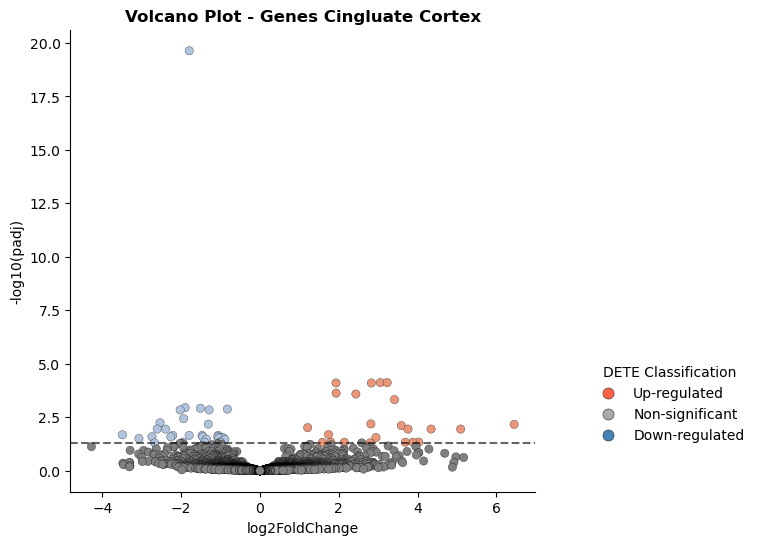

In [5]:

# Organizes the classification, according to the defined values
def organize_classification():
    dea_df['-log10(padj)'] = -np.log10(dea_df['padj'])

    dea_df['Classification'] = dea_df.apply(
        lambda row:
        'Up-regulated' if (row['log2FoldChange'] > 0 and row['padj'] < 0.05)
        else 'Down-regulated' if (row['log2FoldChange'] < -0 and row['padj'] < 0.05)
        else 'Non-significant',
        axis = 1
    )

# Sets the graph's reference lines and labels
def set_lines_and_labels(ax):
    ax.axhline(y = -np.log10(0.05), color = 'black', linestyle = '--', alpha = 0.6)


    ax.set_title('Volcano Plot - Genes Cingluate Cortex', fontweight = 'bold', fontsize = 12)
    ax.set_xlabel('log2FoldChange')
    ax.set_ylabel('-log10(padj)')

# Gets the genes with the biggest change in expression
def get_genes_of_interest():
    significant_df = dea_df[dea_df['Classification'] != 'Non-significant']
    top_up = significant_df.nlargest(5, 'log2FoldChange')['Gene'].tolist()
    top_down = significant_df.nsmallest(5, 'log2FoldChange')['Gene'].tolist()
    genes_of_interest = top_up + top_down

    dea_df['Classification'] = np.where(dea_df['Gene'].isin(genes_of_interest), 
                                        'GOI_' + dea_df['Classification'],
                                        dea_df['Classification'])
    
    return genes_of_interest

# Sets the genes of interest's names on the graph
def set_genes_of_interest_legend(ax):
    global genes_of_interest
    genes_of_interest = get_genes_of_interest()
    texts = []
    for i, row in dea_df.iterrows():
        if row['Gene'] in genes_of_interest:
            texts.append(ax.text(row['log2FoldChange'], row['-log10(padj)'], row['Gene'],
                         fontsize = 7, color = 'black', fontweight = 'semibold'))
            
    adjust_text(texts, expand_points = (1.5, 1.5), arrowprops = dict(arrowstyle = '-', color = 'black', lw = 0.8), save_steps = False)
    print(texts)

# Sets the main chart legend on the plot
def set_plot_legends(ax):
    #set_genes_of_interest_legend(ax)
    legend_elements = [Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'tomato',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3, 
                            label = 'Up-regulated'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'darkgray',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Non-significant'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'steelblue',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Down-regulated')]
    ax.legend(handles = legend_elements, title = 'DETE Classification', bbox_to_anchor = (1.1, 0.3), frameon = False)

    

# Main function, gets the volcano plot
def get_volcano_plot():
    organize_classification() # Organiza-se primeiro a tabela com a classificação

    fig, ax = plt.subplots(figsize = (6, 6)) # Criamos o gráfico
    
    palette_dea = {'GOI_Up-regulated' : 'tomato',
                   'GOI_Down-regulated' : 'steelblue',
                   'Up-regulated' : 'darksalmon',
                   'Down-regulated' : 'lightsteelblue',
                   'Non-significant' : 'gray'}
    
    sns.scatterplot(data = dea_df,  
                    x = 'log2FoldChange', 
                    y = '-log10(padj)',
                    palette = palette_dea, 
                    hue = 'Classification', 
                    edgecolor = 'black',
                    linewidth = 0.2, 
                    legend = False)
    
    set_lines_and_labels(ax) # Colocamos as labels que queremos
    set_plot_legends(ax) # Colocamos as legendas por último
    sns.despine()
    plt.show()
    
get_volcano_plot()



PCA - Data frame

In [6]:
# Variables
genes = expression_df.iloc[:, 0]
counts = expression_df.iloc[:, 1:]
clinical_data = pd.read_csv(CLINICAL_DATA)

# Process counts
library_size = counts.sum(axis = 0)
cpm_df = counts.div(library_size, axis = 1) * 1e6
log2cpm_df = np.log2(cpm_df + 1)
print(log2cpm_df.head())

# Process clinical data
clinical_data = clinical_data[['Sample Name', 'Condition', 'Run']]
print('clinical_data')
print(clinical_data.head())

# Scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(log2cpm_df.T)

pca = PCA(n_components = 2)
pca_res = pca.fit_transform(scaled_data)

# PCA data frame
pca_df = pd.DataFrame(pca_res, index = log2cpm_df.columns, columns = [f"PC{i+1}" for i in range(2)])
pca_df.reset_index(names = 'Sample Name', inplace = True)
pca_df = pca_df.merge(clinical_data, on = 'Sample Name', how = 'left')

pca_df




   GSM3673208  GSM3673209  GSM3673210  GSM3673211  GSM3673212  GSM3673213  \
0    0.698690    0.463252    0.000000    0.412688    0.329872    0.535368   
1    1.581929    0.988760    1.349319    1.453444    1.393442    1.270303   
2    0.087195    0.105315    0.315460    0.221050    0.000000    0.401562   
3    0.583447    0.295356    0.793458    0.412688    0.228071    1.064321   
4    0.997726    0.295356    0.492978    1.054003    0.424961    0.329697   

   GSM3673214  GSM3673215  
0    0.178524    0.092078  
1    1.392103    1.440160  
2    0.000000    0.092078  
3    0.568511    0.260282  
4    0.480446    0.410907  
clinical_data
  Sample Name Condition         Run
0  GSM3673208      Ctrl  SRR8734756
1  GSM3673209      Ctrl  SRR8734757
2  GSM3673210      Ctrl  SRR8734758
3  GSM3673211      Ctrl  SRR8734759
4  GSM3673212       RTT  SRR8734760


,Sample Name,PC1,PC2,Condition,Run
0,GSM3673208,125.833266,-17.932431,Ctrl,SRR8734756
1,GSM3673209,-87.644666,-57.257635,Ctrl,SRR8734757
2,GSM3673210,-62.007998,-20.672922,Ctrl,SRR8734758
3,GSM3673211,121.010943,-60.828344,Ctrl,SRR8734759
4,GSM3673212,-125.358514,58.868472,RTT,SRR8734760
5,GSM3673213,75.190350,99.116018,RTT,SRR8734761
6,GSM3673214,-103.502773,-20.735509,RTT,SRR8734762
7,GSM3673215,56.479392,19.442351,RTT,SRR8734763


PCA - Graph

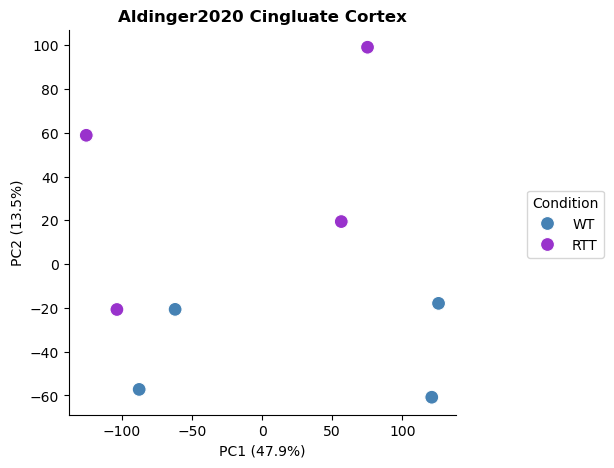

In [7]:
fig, ax = plt.subplots(figsize = (5, 5))
palette_pca = {'WT' : 'steelblue',
               'RTT' : 'darkorchid'}

pca_df['Condition'] = pca_df['Condition'].replace({'Ctrl' : 'WT'})
sns.scatterplot(data = pca_df, x = 'PC1', y = 'PC2', palette = palette_pca, hue = 'Condition', s = 100)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)") # f-string é uma forma moderna de formatar strings em python, valor da variância * 100 para meter em percentagem e dps coloca só com uma casa decimal
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Aldinger2020 Cingluate Cortex", fontweight = 'bold', fontsize = 12)
ax.legend(title = 'Condition', bbox_to_anchor = (1.4, 0.6))
sns.despine()
plt.show()


Boxplot

In [8]:
# Assemble the new table
log2cpm_df.insert(0, 'Gene', genes)
goi_df = log2cpm_df[log2cpm_df['Gene'].isin(genes_of_interest)]

long_df = goi_df.melt(id_vars = 'Gene', var_name = 'Sample_Name', value_name = 'log2(CPM)')
long_df = long_df.merge(clinical_data, on = 'Sample_Name', how = 'left')

print(clinical_data.head())

# Assemble the plot

fig, ax = plt.subplots(figsize = (12, 12))

palette_boxplot = {'RTT' : 'tomato',
                   'Ctrl' : 'steelblue'}

sns.boxplot(data = long_df, x = 'Gene', y = 'log2(CPM)', hue = 'Condition', palette = palette_boxplot,
                fliersize = 2, linewidth = 2)

ax.set_title('Boxplot Genes Cingluate Cortex', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Genes')
ax.set_ylabel('log2(CPM)')
ax.tick_params(axis = 'x', rotation = 45)



TypeError: only list-like objects are allowed to be passed to isin(), you passed a `NoneType`